In [6]:
#Lab 1.1 — “Hello Deep Learning: Build & Serve a First Classifier”
#1 Open Jupyter & setup
import torch, torch.nn as nn, torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

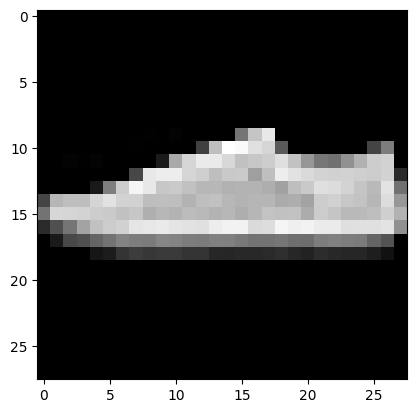

In [5]:
#2 Load Data & Visualize
tfm = transforms.Compose([transforms.ToTensor()])
train = datasets.FashionMNIST('data', train=True, download=True, transform=tfm)
test  = datasets.FashionMNIST('data', train=False, download=True, transform=tfm)
train_dl = DataLoader(train, batch_size=256, shuffle=True)
test_dl = DataLoader(test, batch_size=256)
images, labels = next(iter(train_dl))
plt.imshow(images[0].squeeze(), cmap='gray')
plt.show()

In [1]:
#3 Define baseline model (logistic regression)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader # Critical missing import
from torchvision import datasets, transforms

model = nn.Linear(28*28, 10)
opt = torch.optim.SGD(model.parameters(), lr=0.1)

# Define the transformation
tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load the Test Dataset
test_ds = datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=tfms
)

# Create the DataLoader
test_dl = DataLoader(test_ds, batch_size=1024, shuffle=False)

100%|██████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [01:29<00:00, 111kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 143kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:11<00:00, 141kB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<?, ?B/s]


In [ ]:
#4 Train 5 epochs
def train_epoch():
    model.train()
    loss_sum = 0
    for x, y in train_dl:
        # Move to device (assuming 'device' is defined, e.g., 'cuda' or 'cpu')
        x, y = x.to(device), y.to(device)
        
        # Flatten only if using a Linear/MLP model
        x = x.view(x.size(0), -1) 
        
        opt.zero_grad()
        out = model(x)
        loss = F.cross_entropy(out, y)
        loss.backward()
        opt.step()
        
        # Multiply by batch size to get the total loss for this batch
        loss_sum += loss.item() * x.size(0)  
    # Divide by the total number of samples in the dataset
    return loss_sum / len(train_dl.dataset)

In [3]:
#5 Evaluate & confusion matrix
import numpy as np, sklearn.metrics as M
model.eval()
preds, targs = [], []
device = next(model.parameters()).device # Automatically detect where the model is

with torch.no_grad():
    for x, y in test_dl:
        # 1. Move data to the correct device
        x, y = x.to(device), y.to(device)
        
        # 2. Forward pass (flattening for your Linear baseline)
        out = model(x.view(x.size(0), -1))
        
        # 3. Get predictions and store
        p = out.argmax(dim=1)
        preds.extend(p.cpu().numpy()) # Use extend for efficiency
        targs.extend(y.cpu().numpy())

print(f"Accuracy: {M.accuracy_score(targs, preds):.4f}")
print("Confusion Matrix:")
print(M.confusion_matrix(targs, preds))

Accuracy: 0.1010
Confusion Matrix:
[[ 58  83   0   1   8  27   1 376 308 118]
 [ 84  34  21 224   0  24  73  29 646   0]
 [ 32  68   3  15   6 155  45 202 478  28]
 [111  43   0  49  11  47  91 250 337  71]
 [ 87   8  17  64  12  17  61 210 398 108]
 [181  19   2  16   5   2  81  80 484  22]
 [129  94   0   2   1  32   5 118 568   9]
 [ 18   2   0  82   0  13  29 292 425 167]
 [ 25  22   2   9   4   5 159 331 412   5]
 [ 72   4   1  75   2  12  24 181 495 143]]


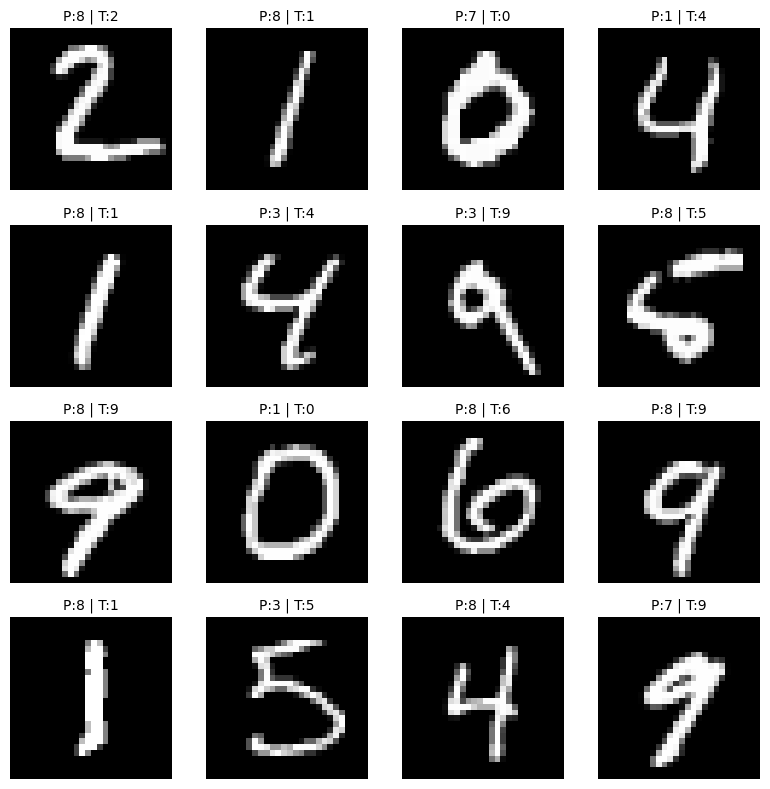

In [5]:
#6 Inspect top mistakes
import itertools
import matplotlib.pyplot as plt

# 1. Identify the indices where predictions don't match targets
wrong = [i for i, (p, t) in enumerate(zip(preds, targs)) if p != t][:16]

grid = plt.figure(figsize=(8, 8)) # Slightly larger for better readability

for j, i in enumerate(wrong):
    ax = grid.add_subplot(4, 4, j + 1)
    
    # Use 'test_ds' (the name defined in step 3)
    img, _ = test_ds[i] 
    
    # squeeze() removes the channel dimension (1, 28, 28) -> (28, 28)
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"P:{preds[i]} | T:{targs[i]}", fontsize=10)
    ax.axis('off') # Cleaner than setting xticks/yticks to []

plt.tight_layout()
plt.show()